In [10]:
from mnist_classifier import MNISTClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# MNIST Digit Recognizer: Machine Learning Pipeline
## Exploratory Data Analysis (EDA)

In this section, we will load the Kaggle MNIST dataset and visualize it to understand the distribution of our classes and the natural variance in human handwriting.

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots render directly below the code cells
%matplotlib inline

# Load the data
print("Loading dataset...")
df = pd.read_csv("train.csv")

# Separate labels from pixel features
y = df['label']
X = df.drop('label', axis=1)

print(f"Dataset loaded! Total images: {len(X)}")
print(f"Number of features (pixels) per image: {X.shape[1]}")

Loading dataset...
Dataset loaded! Total images: 42000
Number of features (pixels) per image: 784


### 1.1 Class Distribution
First, we need to check if our dataset is balanced. If we have significantly more of one digit than others, our models might become biased.

/tmp/ipykernel_10319/157988263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


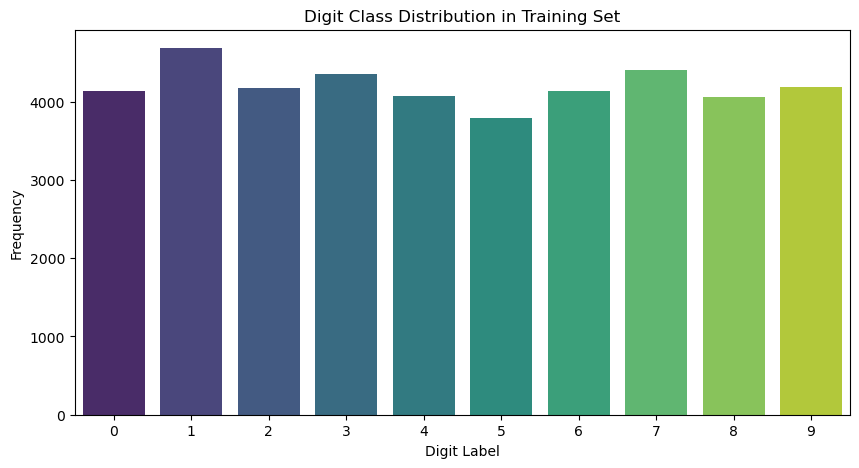

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y, palette="viridis")
plt.title("Digit Class Distribution in Training Set")
plt.xlabel("Digit Label")
plt.ylabel("Frequency")
plt.show()

### 1.2 Visualizing the Digits
To understand the complexity of the problem, let's look at a random sample of the handwritten digits. This shows us the natural variance (e.g., how differently people draw the number '7' or '4').

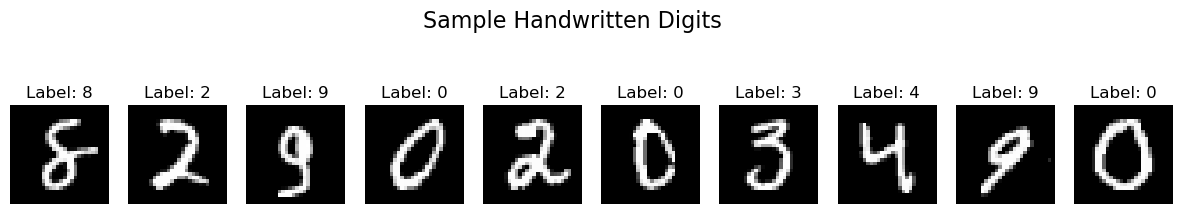

In [13]:
plt.figure(figsize=(15, 3))

# Pick 10 random indices
num_digits = 10
random_indices = np.random.randint(0, len(X), num_digits)

for i, idx in enumerate(random_indices):
    plt.subplot(1, num_digits, i + 1)
    # Reshape the 784 pixels back into a 28x28 grid
    image = X.iloc[idx].values.reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y.iloc[idx]}")
    plt.axis('off')
    
plt.suptitle("Sample Handwritten Digits", fontsize=16)
plt.show()

### 1.3 The "Average" Digit
By calculating the mean pixel intensity across all images of a specific digit, we can see the "fuzzy" prototype of each number. Digits that are blurrier (like 8 or 9) have higher variance in how they are written.

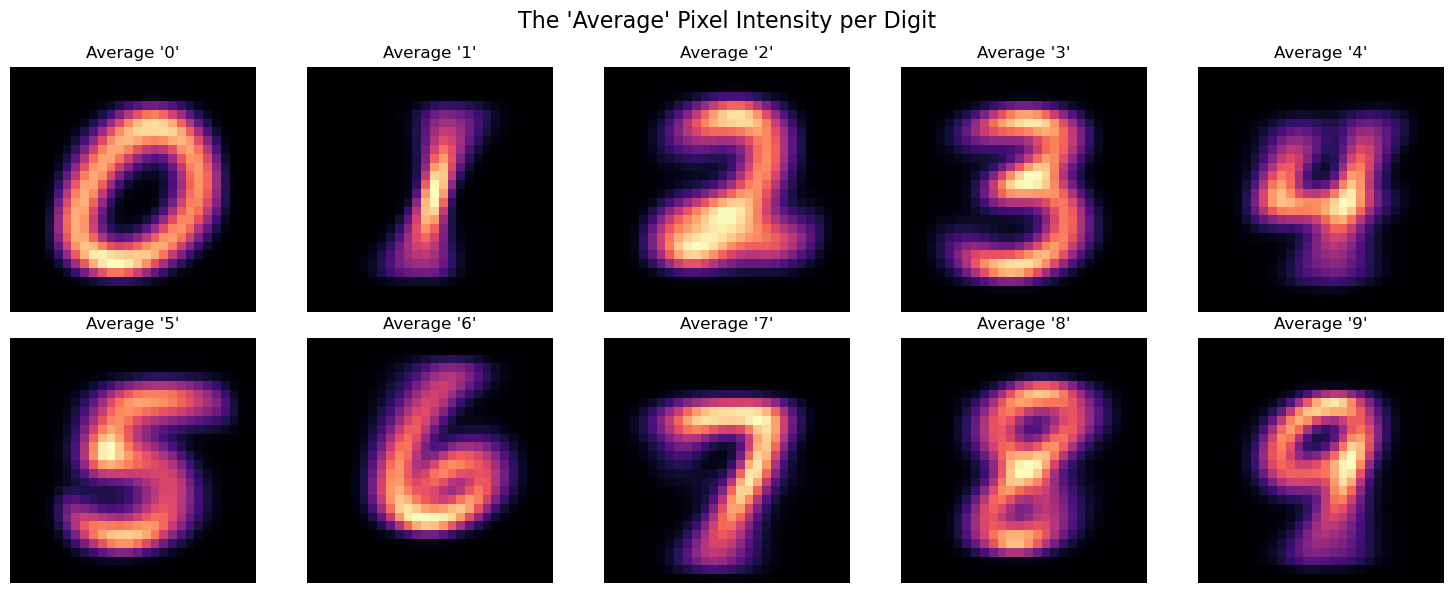

In [14]:
plt.figure(figsize=(15, 6))

for digit in range(10):
    # Filter the dataset for the current digit
    digit_data = X[y == digit]
    
    # Calculate the average pixel values
    avg_image = digit_data.mean(axis=0).values.reshape(28, 28)
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(avg_image, cmap='magma')
    plt.title(f"Average '{digit}'")
    plt.axis('off')
    
plt.suptitle("The 'Average' Pixel Intensity per Digit", fontsize=16)
plt.tight_layout()
plt.show()

## Step 2: Feature Processing & Engineering

Before feeding our images into an algorithm, we need to optimize the data. 
1. **Normalization:** Machine learning models (especially SVMs and Neural Networks) struggle with large numbers. We will scale our pixel values from `0 - 255` down to `0.0 - 1.0`.
2. **Dimensionality Reduction (PCA):** Images have 784 pixels (features), but many of these pixels are completely useless (like the black edges of the image where nobody writes). We will use Principal Component Analysis to compress the data into fewer, more meaningful features.

In [15]:
# 1. Normalization (Scaling)
print("Normalizing pixel values...")
# Dividing by 255 scales all values to be between 0 and 1
X_scaled = X / 255.0

print(f"Max pixel value before: {X.iloc[0].max()}")
print(f"Max pixel value after: {X_scaled.iloc[0].max()}")

Normalizing pixel values...
Max pixel value before: 255
Max pixel value after: 1.0


### 2.1 Analyzing Principal Components
PCA creates new "super features" by combining our pixels. But how many of these new features do we actually need to keep? 

Let's fit PCA on our data and plot the **Cumulative Explained Variance**. This will show us exactly how many components we need to retain, say, 95% of the visual information.

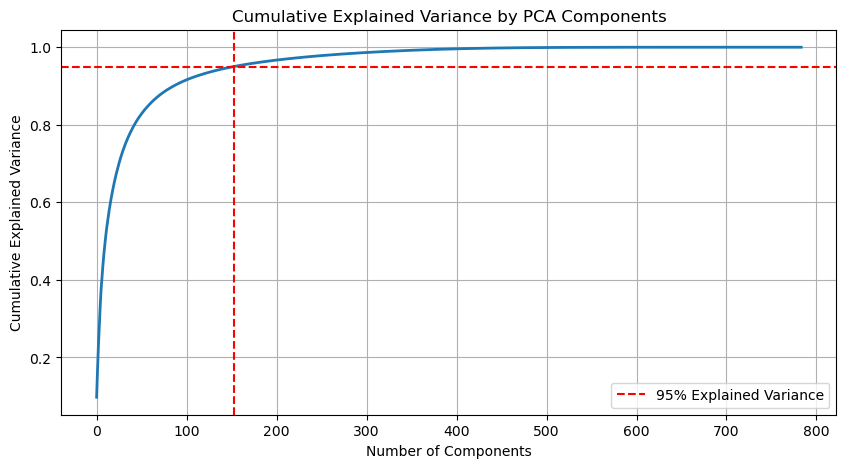

To keep 95% of the information, we only need 153 components (down from 784!)


In [16]:
from sklearn.decomposition import PCA

# Fit PCA on the scaled data without reducing dimensions yet
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the variance curve
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95), color='r', linestyle='--')

plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

# Find exact number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"To keep 95% of the information, we only need {n_components_95} components (down from 784!)")

### 2.2 Applying PCA and Visualizing the Reconstruction
The chart above shows a massive mathematical shortcut! We can throw away over 600 pixels and still keep 95% of the core shapes. 

Let's apply this compression. To prove to ourselves that the model can still "see" the digits, we will reconstruct an image from the compressed data and compare it to the original.

Original shape: (42000, 784)
Compressed shape: (42000, 154)


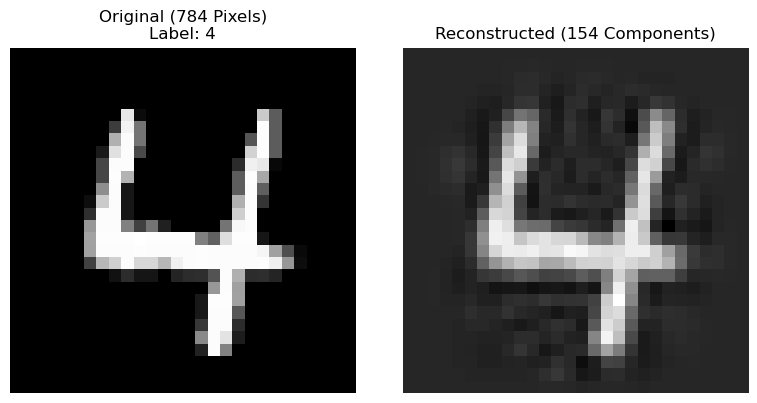

In [17]:
# 1. Apply PCA to keep 95% of the variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"Compressed shape: {X_pca.shape}")

# 2. Reconstruct the image from the compressed features
X_reconstructed = pca.inverse_transform(X_pca)

# 3. Plot Original vs. Reconstructed
plt.figure(figsize=(8, 4))

# Pick a random image to display
sample_index = 42 

# Original
plt.subplot(1, 2, 1)
plt.imshow(X_scaled.iloc[sample_index].values.reshape(28, 28), cmap='gray')
plt.title(f"Original (784 Pixels)\nLabel: {y.iloc[sample_index]}")
plt.axis('off')

# Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[sample_index].reshape(28, 28), cmap='gray')
plt.title(f"Reconstructed ({X_pca.shape[1]} Components)")
plt.axis('off')

plt.tight_layout()
plt.show()